
# Exercises XP - Diabetes Classification

## What you will learn
- Understanding the problem
- Data collection
- Model training for classification
- Model evaluation

## What you will create
- A Logistic Regression model to predict diabetes



## Exercise 1 - Understanding the problem and Data Collection

We want to predict if an individual has diabetes.

- Load the diabetes dataset and explore it
- Count positive and negative cases
- Split the data into train and test


In [14]:
import pandas as pd
# TODO: load the dataset
# If running on Colab, upload the zip or csv then adjust the path

df= pd.read_csv('diabetes_prediction_dataset.csv')

print(df.shape)
display(df.head())
print(df.dtypes)
print("Missing per column:")
display(df.isna().sum().sort_values(ascending=False))


(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object
Missing per column:


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [15]:
# Assume target column is named 'diabetes' with 0 or 1 values
assert 'diabetes' in df.columns, "Expected a 'diabetes' target column"
print(df['diabetes'].value_counts())


diabetes
0    91500
1     8500
Name: count, dtype: int64


In [16]:

# TODO: train test split
from sklearn.model_selection import train_test_split
X = df.drop(columns=['diabetes'])
y = df['diabetes']
X_train, X_test, y_train, y_test = train_test_split(X, y)
print(X_train.shape, X_test.shape)


(75000, 8) (25000, 8)



## Exercise 2 - Model picking and standardization

- Which model can we use and why
- Do we need to standardize
- If yes, apply StandardScaler



> TODO: In a short paragraph, justify Logistic Regression for this binary task. Mention linear decision boundary, calibrated probabilities, and interpretability. Explain why standardization helps for numerical stability and better conditioning.

Logistic Regression is a good choice for this binary task because it effectively models binary outcomes and provides a linear decision boundary in the feature space, which allows for clear separation between diabetic and non-diabetic classes. It is also valuable because it produces calibrated probabilities through the sigmoid function, which is useful in a medial context in that it provides a patient's risk level (probability of having diabetes). The model offers high interpretability, as we can see the effect of every variable: the exponentiated coefficients represent odds ratios, indicating how much each factor increases the likelihood of diabetes. Standardization of numerical features is important for proper performance of this model because it centers and scales the data, ensuring the model treats all features equally (preventing features with larger magnitudes from being treated as more important), leading to better conditioning and improved numerical stability.

In [17]:
# TODO: build a preprocessing pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = X.select_dtypes(include=['str','object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
print("Categorical:", cat_cols)
print("Numeric:", num_cols)


Categorical: ['gender', 'smoking_history']
Numeric: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']


## Exercise 3 - Model training

In [18]:

# TODO: train Logistic Regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

clf = Pipeline([
    ('preprocessor', preprocess),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
])
clf.fit(X_train, y_train)
print("Classes identified by the model:", clf.classes_)

Classes identified by the model: [0 1]



## Exercise 4 - Evaluation metrics

- Plot accuracy and comment
- Plot confusion matrix and comment
- Plot precision, recall, F1 and comment


Accuracy: 0.8902
Precision: 0.4282
Recall: 0.8833
F1: 0.5768


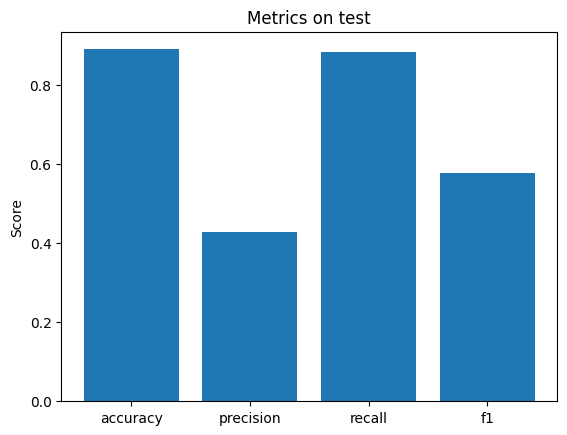

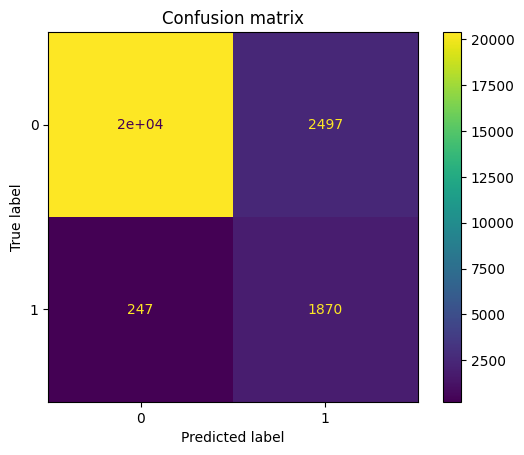

In [19]:
# TODO: use the metrics functions properly to plot the scores
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(acc,4))
print("Precision:", round(prec,4))
print("Recall:", round(rec,4))
print("F1:", round(f1,4))

# Simple bar plot of metrics
import matplotlib.pyplot as plt
plt.figure()
plt.bar(['accuracy','precision','recall','f1'], [acc,prec,rec,f1])
plt.title('Metrics on test')
plt.ylabel('Score')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('Confusion matrix')
plt.show()


> TODO: comment on the balance between precision and recall.

With this model, Precision is low (0.4213) and Recall is high (0.8807). Note that precision is the proportion of true positives out of total positive results (true positives and false positives), so a low precision indicates many false positives (in this case, indications of diabetes that were inaccurate); recall is the proportion of true positives out of total actual positives (true positives and false negatives), so a high recall indicates very few false negatives (in this case, missed cases of diabetes). In the case of diabetes screening, it is very important to predict as many cases of diabetes as possible, and there is a large cost of a false negative, missing a case of diabetes (adverse health consequences), whereas there is a low cost of a false positive (estimating diabetes incidence, where the cost is merely the cost of an additional test to confirm diabetes incidence which would come out negative). Therefore the outcome of having low precision and high recall is satisfactory and a reasonable balance of the precision-recall tradeoff. 


## Exercise 5 - Visualizing the performance of our model

Visualize a 2D decision boundary with accuracy info. Use only two informative features for this plot to keep it 2D. Suggested pair: `HbA1c_level` and `blood_glucose_level` if present. Otherwise pick any two numeric features.


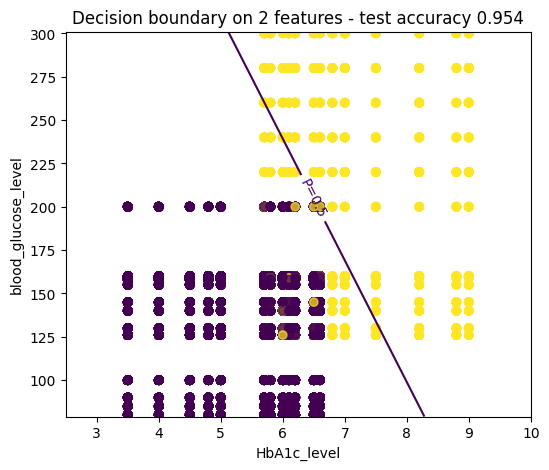

In [20]:
# TODO: If these columns do not exist, change `feat_x` and `feat_y` below to two numeric features that exist in your data.
import numpy as np
import matplotlib.pyplot as plt

feat_x = 'HbA1c_level' if 'HbA1c_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[0]
feat_y = 'blood_glucose_level' if 'blood_glucose_level' in X.columns else X.select_dtypes(include=['int64','float64']).columns[1]

X2_train = X_train[[feat_x, feat_y]].copy()
X2_test = X_test[[feat_x, feat_y]].copy()

pipe2 = Pipeline([
    ('pre', ColumnTransformer([('num', StandardScaler(), [0,1])], remainder='drop')),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])
pipe2.fit(X2_train.values, y_train)

# Mesh
x_min, x_max = X2_train[feat_x].min()-1, X2_train[feat_x].max()+1
y_min, y_max = X2_train[feat_y].min()-1, X2_train[feat_y].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
probs = pipe2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

plt.figure(figsize=(6,5))
cs = plt.contour(xx, yy, probs, levels=[0.5])
plt.clabel(cs, inline=True, fmt={0.5: 'P=0.5'})
plt.scatter(X2_test[feat_x], X2_test[feat_y], c=y_test, alpha=0.7)
plt.xlabel(feat_x); plt.ylabel(feat_y)
from sklearn.metrics import accuracy_score
acc2 = accuracy_score(y_test, pipe2.predict(X2_test.values))
plt.title(f'Decision boundary on 2 features - test accuracy {acc2:.3f}')
plt.show()



## Exercise 6 - ROC curve

Use the code template provided to plot the ROC curve for your model and compute AUC. You can reuse the fitted `clf` pipeline.

Template summary:
- Get predicted probabilities for the positive class
- Compute fpr and tpr with `roc_curve`
- Plot ROC and print AUC


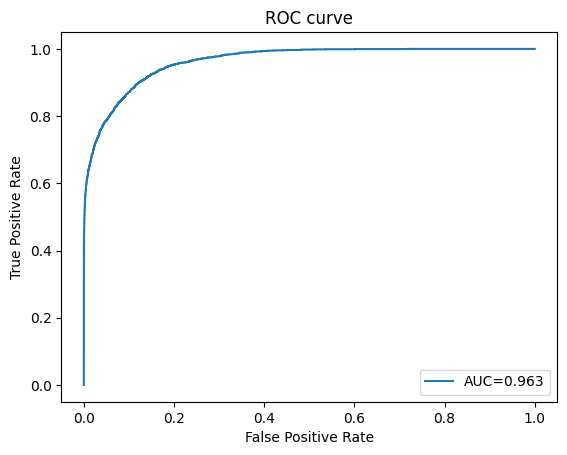

In [21]:

from sklearn import metrics
y_proba = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba)
auc = metrics.roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC={auc:.3f}')
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.title('ROC curve')
plt.show()


> TODO: interpret the ROC curve and AUC from results of execution of cell above.

The ROC curve illustrates the tradeoff between the false positive rate (the probability that the model incorrectly flags a "negative" case as positive--a false alarm) and the true positive rate (the probability that the model correctly identifies a "positive" case when the truth is positive) for this model and the given testing data. It shows that in this context it is possible to maintain a near-zero false positive rate when achieving a 0.6 true positive rate, but to get a 0.8 true positive rate requires having 0.1 false positive rate, and reaching close to 1 (around 0.99) true positive rate requires about a 0.4 false positive rate.
The AUC is the Area Under the ROC Curve. Mathematically, it indicates the probability the model will rank a randomly chosen positive instance higher than a randomly chosen negative instance. In this test of the model, the AUC is 0.961, which is considered excellent. It means that there is a 96.1% chance that if you pick one person with diabetes and one person without at random, the model will assign a higher risk probability to the person with diabetes. This indicates there is very little overlap in the distributions of the two classes, and the model is very confident in its classification. With this high an AUC, there is room to adjust the decision threshold, likely achieving a high recall while maintaining low false positive rate. However, full examination of the test results should involve looking at class balance. If there is high class imbalance, it is worth checking the precision-recall curve as well to ensure the model is good at identifying the rare class.